# === Install Necessary Libraries ===

In [1]:
!pip install lightning timm torch-xla
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


# === Imports ===

In [2]:
import os
import pandas as pd
import numpy as np
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import lightning.pytorch as L
from lightning.pytorch import LightningModule, Trainer, LightningDataModule
# import torch_xla.core.xla_model as xm
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# === Verify TPU ===

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Data Paths ===

In [4]:
train_df = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/train.csv')
test_df  = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')
img_dir  = '/kaggle/input/ai-vs-human-generated-dataset/'

# --- Create Pair IDs and Split Train/Validation (Pair-Aware) ---
train_df['pair_id'] = train_df.index // 2
unique_pairs = train_df['pair_id'].unique()

In [5]:
train_df

,Unnamed: 0,file_name,label,pair_id
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1,0
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0,1
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1,2
...,...,...,...,...
79945,79945,train_data/9283b107f6274279b6f15bbe77c523aa.jpg,0,39972
79946,79946,train_data/4c6b17fe6dd743428a45773135a10508.jpg,1,39973
79947,79947,train_data/1ccbf96d04e342fd9f629ad55466b29e.jpg,0,39973
79948,79948,train_data/ff960b55f296445abb3c5f304b52e104.jpg,1,39974


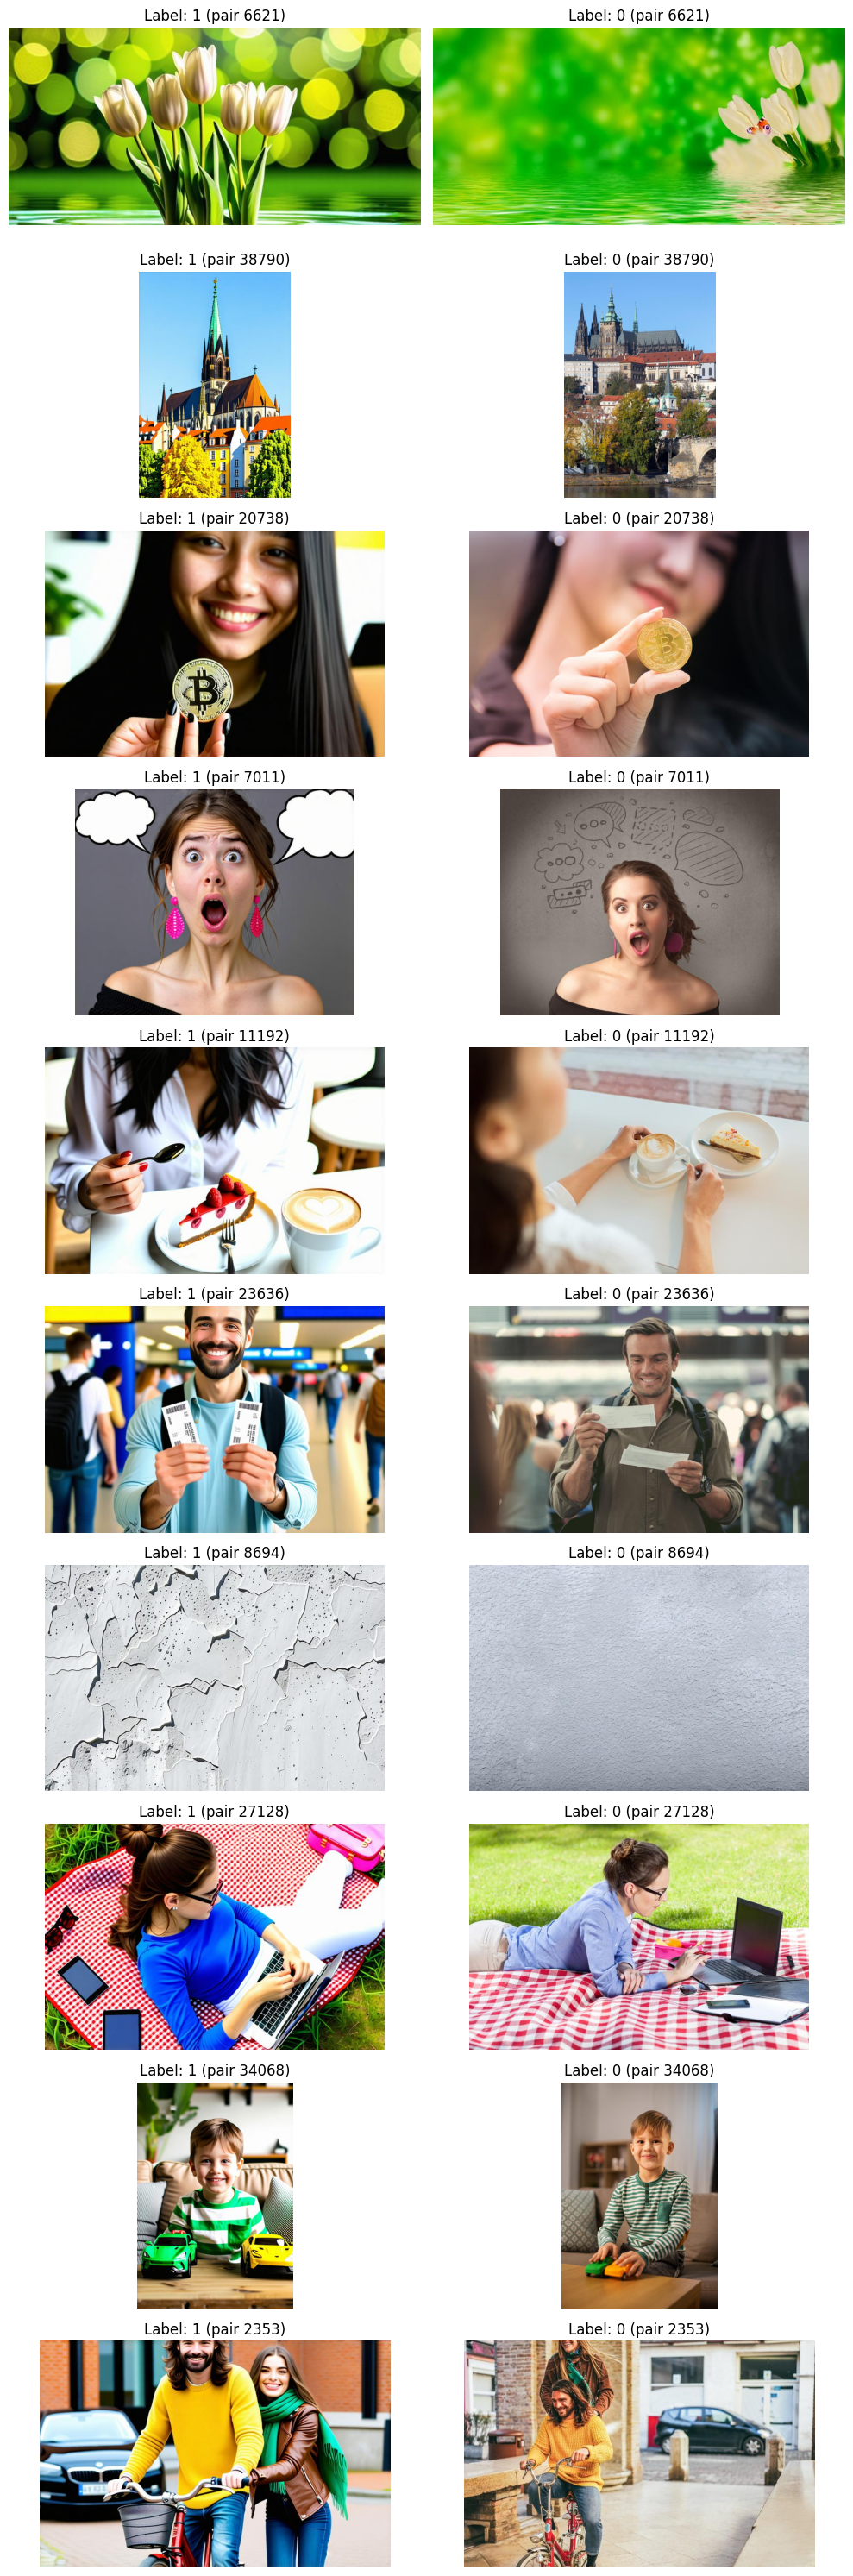

In [6]:
import matplotlib.pyplot as plt
import cv2

# Helper function to show example pairs
def show_pairs(df, img_dir, num_pairs=5):
    unique_pairs = df['pair_id'].unique()
    sample_pairs = np.random.choice(unique_pairs, num_pairs, replace=False)

    plt.figure(figsize=(10, num_pairs*3))

    for i, pid in enumerate(sample_pairs):
        pair_data = df[df['pair_id'] == pid]

        for j, row in enumerate(pair_data.itertuples()):
            img_path = f"{img_dir}/{row.file_name}"
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(num_pairs, 2, i*2 + j + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Label: {row.label} (pair {pid})")

    plt.tight_layout()
    plt.show()

# Show 5 random pairs
show_pairs(train_df, img_dir, num_pairs=10)

In [7]:
# Subsample to 20% for faster training
train_df = train_df.sample(frac=0.2, random_state=42)
print(f"Using subset of {len(train_df)} samples (20% of original) for faster training")

Using subset of 15990 samples (20% of original) for faster training


In [8]:
train_df_split, temp_df = train_test_split(
    train_df, 
    test_size=0.30, 
    random_state=42, 
    stratify=train_df['label']
)

val_df_split, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['label']
)

In [9]:
print("Training samples:", len(train_df_split), "Validation samples:", len(val_df_split))

Training samples: 11193 Validation samples: 2398


In [10]:
test_df = test_df.rename(columns={'file_name': 'id'})

# === Data Transforms ===

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# TTA transforms (a few variants)
tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
]

In [12]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, is_test=False):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        if self.is_test:
            img_path = os.path.join(self.img_dir, self.dataframe.iloc[idx]['id'])
        else:
            img_path = os.path.join(self.img_dir, self.dataframe.iloc[idx]['file_name'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image, self.dataframe.iloc[idx]['id']
        else:
            label = self.dataframe.iloc[idx]['label']
            return image, label

In [13]:
class ImageDataModule(LightningDataModule):
    def __init__(self, train_df, val_df, test_df, img_dir, batch_size=64):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.img_dir = img_dir
        self.batch_size = batch_size

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            self.train_dataset = CustomDataset(self.train_df, self.img_dir, transform=train_transform)
            self.val_dataset   = CustomDataset(self.val_df, self.img_dir, transform=val_transform)
        if stage == 'test' or stage is None:
            self.test_dataset = CustomDataset(self.test_df, self.img_dir, transform=val_transform, is_test=True)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

In [14]:
def tta_inference_probas(model, dataloader, tta_transforms, device):
    model.eval()
    all_probs = {}
    for batch in tqdm(dataloader, desc="TTA Inference"):
        images, img_ids = batch
        batch_probs = []
        for t in tta_transforms:
            images_tta = torch.stack([t(transforms.ToPILImage()(img.cpu())) for img in images])
            images_tta = images_tta.to(device=device, dtype=torch.bfloat16)  # ✅ cast to bfloat16
            with torch.no_grad():
                outputs = model(images_tta)
                batch_probs.append(F.softmax(outputs, dim=1))
        avg_probs = torch.stack(batch_probs).mean(dim=0)
        for id_, prob in zip(img_ids, avg_probs.cpu()):
            all_probs[id_] = prob
    return all_probs

# === EfficientNetLite Model ===

In [15]:
class EfficientNetLiteClassifier(LightningModule):
    def __init__(self, num_classes=2, lr=1e-4, train_mode="frozen"):
        """
        train_mode: str = ["frozen", "partial", "full"]
        """
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model('tf_efficientnet_lite0', pretrained=True, num_classes=num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

        # Metric storage
        self.train_loss_batches, self.val_loss_batches = [], []
        self.train_acc_batches, self.val_acc_batches = [], []
        self.epoch_train_losses, self.epoch_val_losses = [], []
        self.epoch_train_accs, self.epoch_val_accs = [], []

        # Configure train mode
        self._set_train_mode(train_mode)

    def _set_train_mode(self, mode):
        if mode == "frozen":
            for name, param in self.model.named_parameters():
                param.requires_grad = "classifier" in name
        elif mode == "partial":
            for name, param in self.model.named_parameters():
                # You can choose some blocks to unfreeze if you want
                if "blocks.7" in name or "classifier" in name:
                    param.requires_grad = True
                else:
                    param.requires_grad = False
        elif mode == "full":
            for param in self.model.parameters():
                param.requires_grad = True
        else:
            raise ValueError(f"Invalid train_mode: {mode}")

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.loss_fn(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        self.log('train_loss', loss, prog_bar=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_epoch=True)

        # Store batch metrics
        self.train_loss_batches.append(loss.detach().cpu().item())
        self.train_acc_batches.append(acc.detach().cpu().item())
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.loss_fn(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        self.log('val_loss', loss, prog_bar=True, on_epoch=True)
        self.log('val_acc', acc, prog_bar=True, on_epoch=True)

        # Store batch metrics
        self.val_loss_batches.append(loss.detach().cpu().item())
        self.val_acc_batches.append(acc.detach().cpu().item())
        return loss

    def on_train_epoch_end(self):
        """Aggregate metrics by epoch for plotting."""
        if len(self.train_loss_batches) > 0:
            self.epoch_train_losses.append(sum(self.train_loss_batches) / len(self.train_loss_batches))
            self.epoch_train_accs.append(sum(self.train_acc_batches) / len(self.train_acc_batches))
            self.train_loss_batches.clear()
            self.train_acc_batches.clear()

        if len(self.val_loss_batches) > 0:
            self.epoch_val_losses.append(sum(self.val_loss_batches) / len(self.val_loss_batches))
            self.epoch_val_accs.append(sum(self.val_acc_batches) / len(self.val_acc_batches))
            self.val_loss_batches.clear()
            self.val_acc_batches.clear()

    def on_train_end(self):
        """Plot train/val loss and accuracy after training."""
        epochs = range(1, len(self.epoch_train_losses) + 1)

        plt.figure(figsize=(10, 4))
        # ✅ Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.epoch_train_losses, label="Train Loss")
        if len(self.epoch_val_losses) > 0:
            plt.plot(epochs, self.epoch_val_losses, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training vs Validation Loss")
        plt.legend()

        # ✅ Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.epoch_train_accs, label="Train Acc")
        if len(self.epoch_val_accs) > 0:
            plt.plot(epochs, self.epoch_val_accs, label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Training vs Validation Accuracy")
        plt.legend()

        plt.tight_layout()
        plt.show()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.hparams.lr
        )
        return optimizer


In [16]:
datamodule = ImageDataModule(train_df_split, val_df_split, test_df, img_dir, batch_size=64)

In [17]:
datamodule.setup(stage='test')
test_loader = datamodule.test_dataloader()

In [18]:
true_labels = torch.tensor(test_df["label"].values, dtype=torch.long).to(device)

## Only fine-tunes classification head

In [19]:
model_frozen = EfficientNetLiteClassifier(num_classes=2, train_mode="frozen")

model.safetensors:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | EfficientNet     | 3.4 M  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
2.6 K     Trainable params
3.4 M     Non-trainable params
3.4 M     Total params
6.747     Total estimated model params size (MB)
274       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.


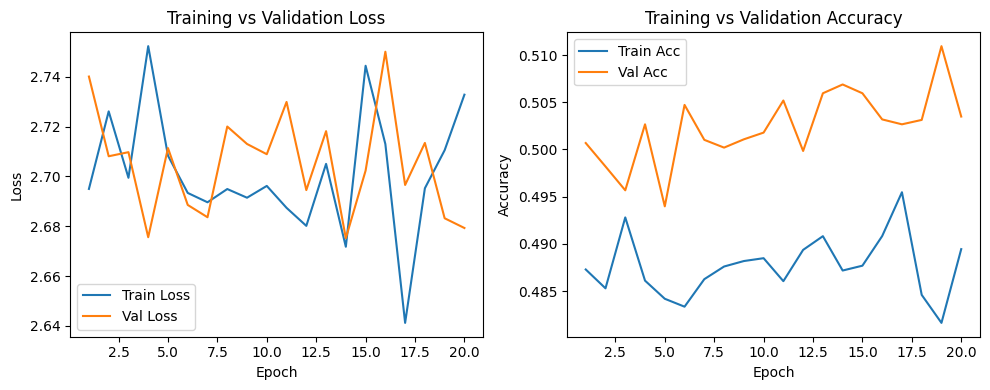

In [20]:
trainer_Efficient = Trainer(
    max_epochs=20,
    accelerator='gpu',
    devices=1,
    precision="bf16-true",
    accumulate_grad_batches=4
)
trainer_Efficient.fit(model_frozen, datamodule=datamodule)

In [21]:
model = model_frozen.to(device)
probs = tta_inference_probas(model, test_loader, tta_transforms, device)

# Create probs tensor in the correct order
probs_tensor = torch.stack([probs[id_] for id_ in test_df['id']])
# true_labels tensor (already in correct order)
true_labels_tensor = torch.tensor(test_df['label'].values).to(probs_tensor.device)

# Compute loss
criterion = torch.nn.CrossEntropyLoss()
test_loss = criterion(probs_tensor, true_labels_tensor).item()

# Compute accuracy
preds = torch.argmax(probs_tensor, dim=1)
test_acc = (preds == true_labels_tensor).float().mean().item()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

TTA Inference: 100%|██████████| 38/38 [00:32<00:00,  1.18it/s]

Test Loss: 0.8086
Test Accuracy: 45.98%


## Fine-tunes last residual block + FC

In [22]:
model_partial = EfficientNetLiteClassifier(num_classes=2, train_mode="partial")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | EfficientNet     | 3.4 M  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
2.6 K     Trainable params
3.4 M     Non-trainable params
3.4 M     Total params
6.747     Total estimated model params size (MB)
274       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.


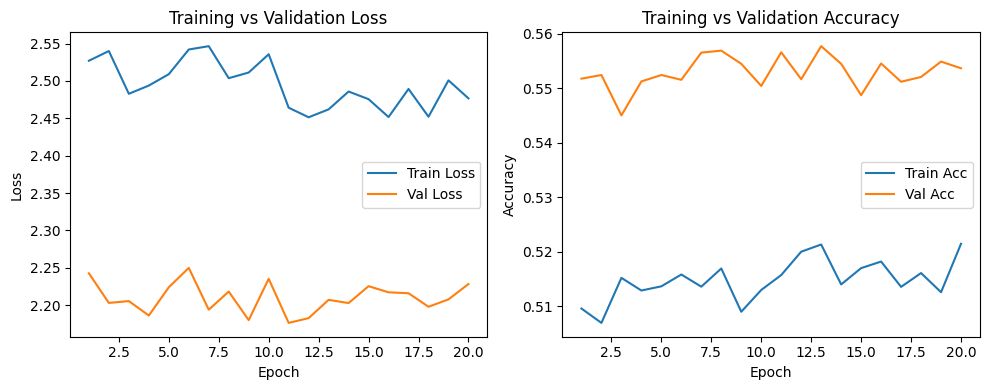

In [23]:
trainer_Efficient = Trainer(
    max_epochs=20,
    accelerator='gpu',
    devices=1,
    precision="bf16-true",
    accumulate_grad_batches=4
)
trainer_Efficient.fit(model_partial, datamodule=datamodule)

In [24]:
model = model_partial.to(device)
probs = tta_inference_probas(model, test_loader, tta_transforms, device)

# Create probs tensor in the correct order
probs_tensor = torch.stack([probs[id_] for id_ in test_df['id']])
# true_labels tensor (already in correct order)
true_labels_tensor = torch.tensor(test_df['label'].values).to(probs_tensor.device)

# Compute loss
criterion = torch.nn.CrossEntropyLoss()
test_loss = criterion(probs_tensor, true_labels_tensor).item()

# Compute accuracy
preds = torch.argmax(probs_tensor, dim=1)
test_acc = (preds == true_labels_tensor).float().mean().item()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

TTA Inference: 100%|██████████| 38/38 [00:30<00:00,  1.23it/s]

Test Loss: 0.7344
Test Accuracy: 53.52%


## Fine-tunes the entire network

In [25]:
model_full = EfficientNetLiteClassifier(num_classes=2, train_mode="full")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | EfficientNet     | 3.4 M  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
6.747     Total estimated model params size (MB)
274       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.


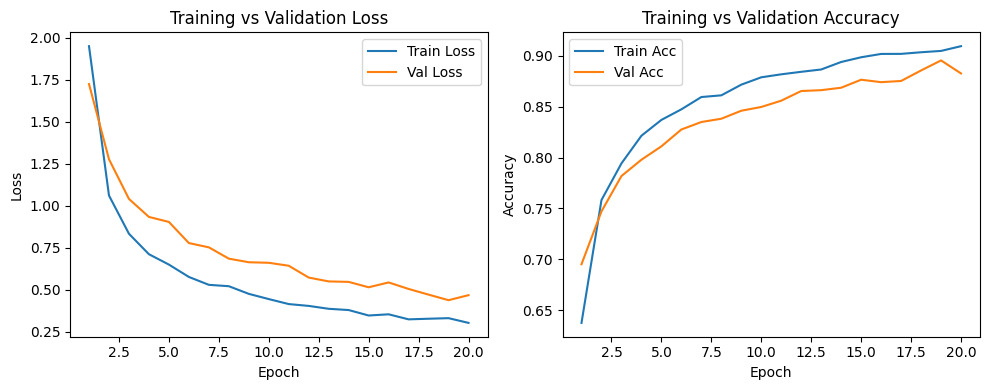

In [26]:
trainer_Efficient = Trainer(
    max_epochs=20,
    accelerator='gpu',
    devices=1,
    precision="bf16-true",
    accumulate_grad_batches=4
)
trainer_Efficient.fit(model_full, datamodule=datamodule)

In [27]:
model = model_full.to(device)
probs = tta_inference_probas(model, test_loader, tta_transforms, device)

# Create probs tensor in the correct order
probs_tensor = torch.stack([probs[id_] for id_ in test_df['id']])
# true_labels tensor (already in correct order)
true_labels_tensor = torch.tensor(test_df['label'].values).to(probs_tensor.device)

# Compute loss
criterion = torch.nn.CrossEntropyLoss()
test_loss = criterion(probs_tensor, true_labels_tensor).item()

# Compute accuracy
preds = torch.argmax(probs_tensor, dim=1)
test_acc = (preds == true_labels_tensor).float().mean().item()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

TTA Inference: 100%|██████████| 38/38 [00:31<00:00,  1.21it/s]

Test Loss: 0.6797
Test Accuracy: 60.23%
